In [1]:
import json
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
with open("WebVoyager_data.jsonl", "r") as f:
    data = [json.loads(line) for line in f]

In [3]:
np.random.seed(12345)
data = np.random.permutation(data).tolist()

In [4]:
from conformal_generation.sequence_selector import RunningMaxSequenceSelector
from conformal_generation.calibration_dataset import IndividualScoreCalibrationDataset
from conformal_generation.conformal_generation import ConformalGeneration
from conformal_generation.utils import plot_admissibility_curve, plot_generation_sequence_length

In [5]:
admissibility_aggregation = lambda a_list: max(a_list) if len(a_list) > 0 else 1
score_fn = lambda x, y: y[-1]["completion"] if len(y) > 0 else 0
# score_fn = lambda x, y: np.mean([step["probability"] for step in y]) if len(y) > 0 else 0
sequence_selector = RunningMaxSequenceSelector(score_fn=score_fn)
x = [(row["name"]) for row in data]
y = [row["interactions"] for row in data]
for row_data, row_y in zip(data, y):
    for j, seq in enumerate(row_y):
        for step in seq:
            step["success"] = row_data["success"][j]
idx = int(0.8 * len(x))
x_train, x_test = x[:idx], x[idx:]
y_train, y_test = y[:idx], y[idx:]
a_data = [row["success"] for row in data]
a_train, a_test = a_data[:idx], a_data[idx:]
n = len(x_train)
calibration_ds = IndividualScoreCalibrationDataset(
    sequence_selector=sequence_selector,
    input_dataset=x_train,
    raw_generated_dataset=y_train,
    admissibility_dataset=a_train,
    admissibility_aggregation=admissibility_aggregation,
)
CG = ConformalGeneration(
    sequence_selector=sequence_selector,
    calibration_dataset=calibration_ds,
)
CG.calibrate(gamma=0.3, recalibrate=True)
selected= CG.select(instance=x_train[11], raw_generated_sequence=y_train[11])
# example usage

In [6]:
gamma_list = np.linspace(0, 1, 51).tolist()
results = {gamma: [] for gamma in gamma_list}
is_lambda_inf = {gamma: False for gamma in gamma_list}
seq_length = {gamma: [] for gamma in gamma_list}
for gamma in gamma_list:
    CG.calibrate(gamma=gamma, recalibrate=True)
    if CG._conformal_threshold == math.inf:
        is_lambda_inf[gamma] = True
        results[gamma] = [1 for _ in range(len(x_test))]
        seq_length[gamma] = [len(y_tmp) for y_tmp in y_test]
        continue
    for i in range(len(x_test)):
        selected = CG.select(instance=x_test[i], raw_generated_sequence=y_test[i])
        results[gamma].append(admissibility_aggregation([item[-1]['success'] for item in selected]))
        seq_length[gamma].append(len(selected))

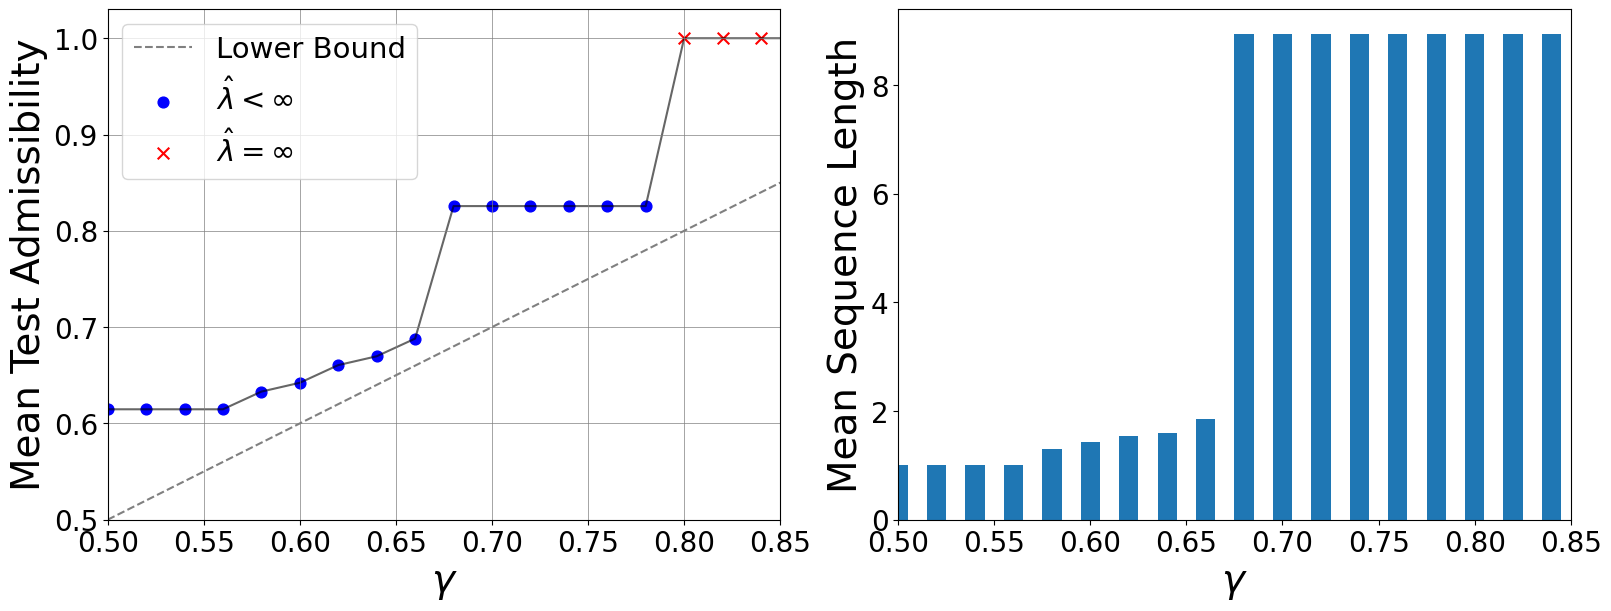

In [7]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16,6), constrained_layout=True)
plot_admissibility_curve(
    ax=ax1,
    admissibility_results={
        gamma: np.mean(results[gamma]) for gamma in gamma_list
    },
    is_lambda_inf=is_lambda_inf,
)
plot_generation_sequence_length(
    ax=ax2,
    avg_length_conformal={
        gamma: np.mean(seq_length[gamma]) for gamma in seq_length
    },
)
ax1.set_xlim(xmin=0.5, xmax=0.85)
ax1.set_ylim(ymin=0.5, ymax=1.03)
ax2.set_xlim(xmin=0.5, xmax=0.85)
for patch in ax2.patches:
    current_width = patch.get_width()
    diff = current_width - 0.01
    patch.set_width(0.01)
    patch.set_x(patch.get_x() + diff / 2)
plt.savefig("webvoyager_results.pdf")
fig.show()

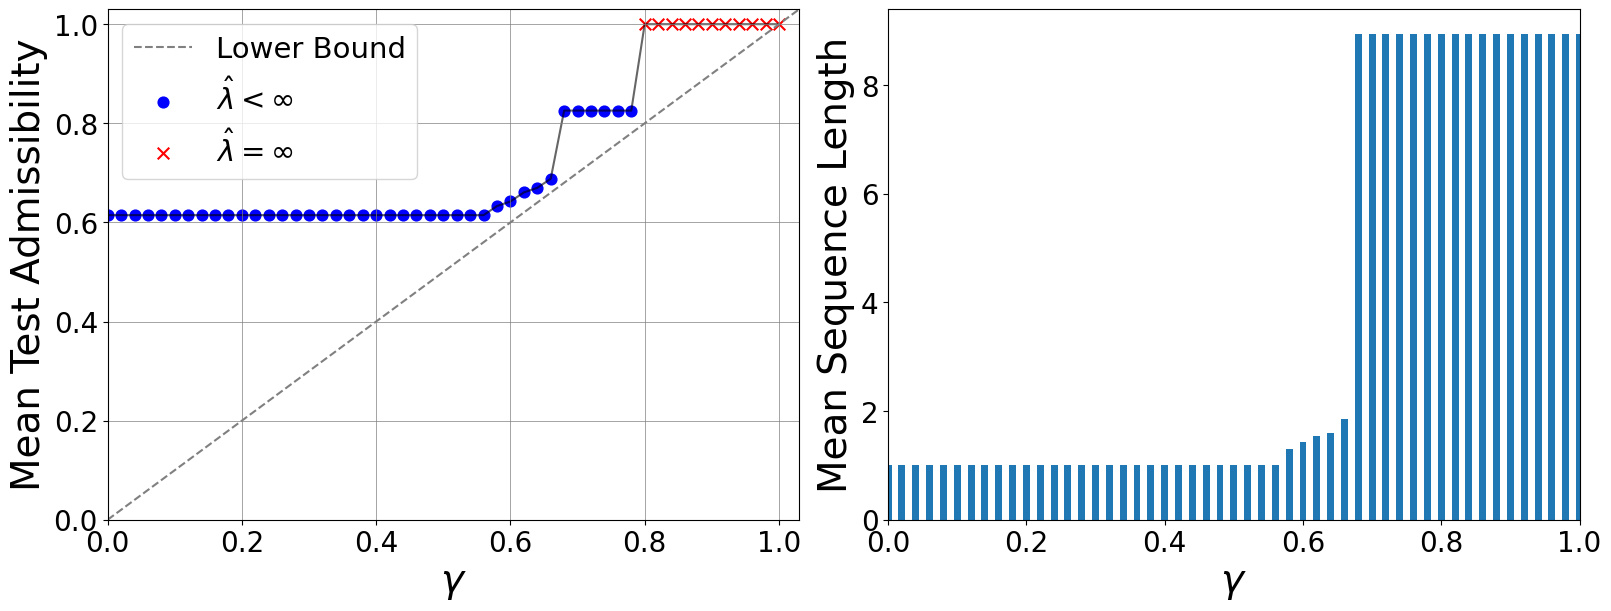

In [8]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16,6), constrained_layout=True)
plot_admissibility_curve(
    ax=ax1,
    admissibility_results={
        gamma: np.mean(results[gamma]) for gamma in gamma_list
    },
    is_lambda_inf=is_lambda_inf,
)
plot_generation_sequence_length(
    ax=ax2,
    avg_length_conformal={
        gamma: np.mean(seq_length[gamma]) for gamma in seq_length
    },
)
for patch in ax2.patches:
    current_width = patch.get_width()
    diff = current_width - 0.01
    patch.set_width(0.01)
    patch.set_x(patch.get_x() + diff / 2)
plt.savefig("webvoyager_results_full.pdf")
fig.show()

In [9]:
results_train = {gamma: [] for gamma in gamma_list}
is_lambda_inf_train = {gamma: False for gamma in gamma_list}
seq_length_train = {gamma: [] for gamma in gamma_list}
for gamma in gamma_list:
    CG.calibrate(gamma=gamma, recalibrate=True)
    if CG._conformal_threshold == math.inf:
        is_lambda_inf_train[gamma] = True
        results_train[gamma] = [1 for _ in range(len(x_train))]
        seq_length_train[gamma] = [len(y_tmp) for y_tmp in y_train]
        continue
    for i in range(len(x_train)):
        selected = CG.select(instance=x_train[i], raw_generated_sequence=y_train[i])
        results_train[gamma].append(admissibility_aggregation([item[-1]['success'] for item in selected]))
        seq_length_train[gamma].append(len(selected))

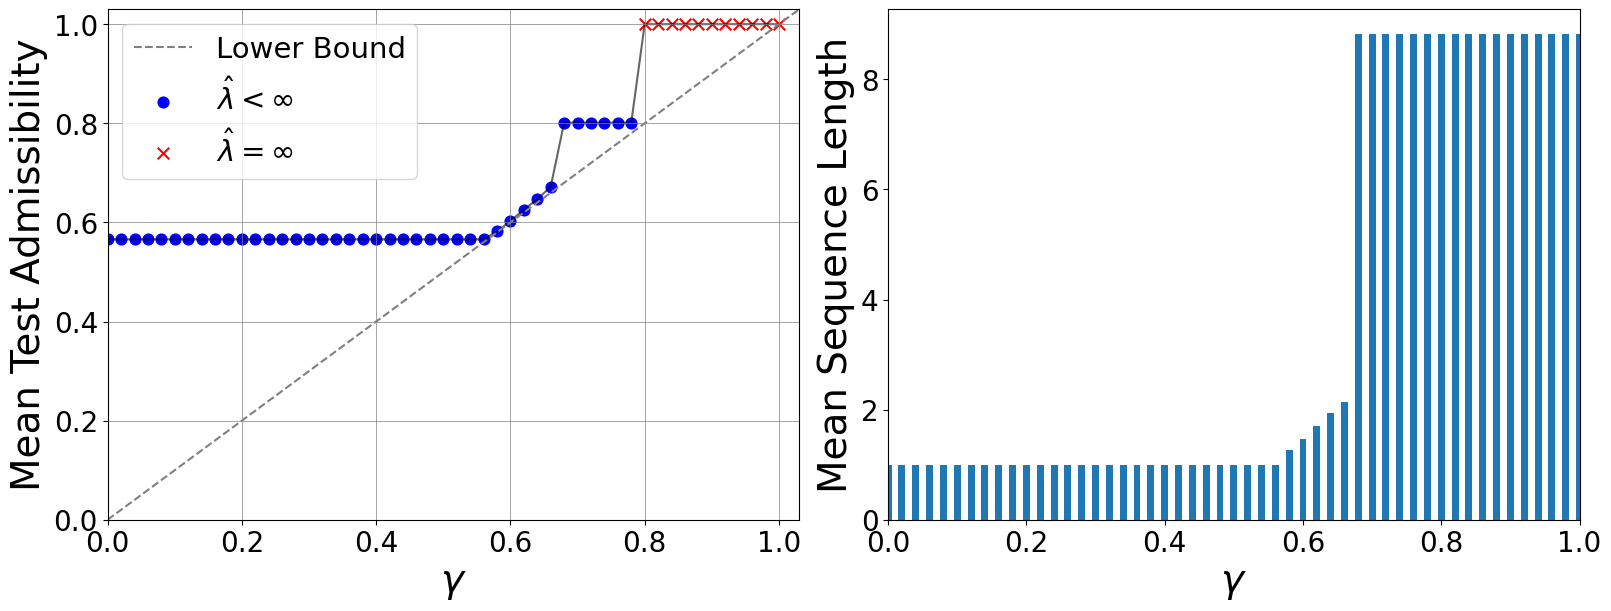

In [10]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16,6), constrained_layout=True)
plot_admissibility_curve(
    ax=ax1,
    admissibility_results={
        gamma: np.mean(results_train[gamma]) for gamma in gamma_list
    },
    is_lambda_inf=is_lambda_inf_train,
)
plot_generation_sequence_length(
    ax=ax2,
    avg_length_conformal={
        gamma: np.mean(seq_length_train[gamma]) for gamma in seq_length_train
    },
)
for patch in ax2.patches:
    current_width = patch.get_width()
    diff = current_width - 0.01
    patch.set_width(0.01)
    patch.set_x(patch.get_x() + diff / 2)
plt.savefig("webvoyager_results_full_train.pdf")
fig.show()